# Oráculo: recuperación de segundo trip por codificación de fase (SZ(8/64))

Oráculo de `docs/algorithms/sz-second-trip-recovery.md`, independiente de cualquier
crate Rust (no existe implementación, ni está comprometida a Stage 1). La propia
página del algoritmo, y el índice de estado de `docs/algorithms/roadmap.md`
("Estado del paso 1 del método"), difieren explícitamente este trabajo — incluido
el paso 1 (oráculo) — a Stage 2, condicionado a que el excitador soporte
modulación de fase programable pulso a pulso (transmisor coherente). **Este
notebook rompe esa deferencia a pedido explícito**: es estudio de algoritmo
únicamente, no cablea nada en `crates/`, y no implica ningún compromiso de
hardware — sigue sin confirmarse si el excitador de la instalación soporta la
fase programable que SZ exige (ver "Configuraciones cubiertas" de la página).

**Procedencia de la fórmula, declarada.** El paper original —Sachidananda &
Zrnić (1999), *Systematic Phase Codes for Resolving Range Overlaid Signals in a
Doppler Weather Radar*, JAOT 16— está bloqueado en este entorno, mismo tipo de
403 ya documentado en `roadmap.md` para AMS/ResearchGate en el intento de fase 4.
La fórmula exacta del código se tomó de una fuente secundaria abierta que sí cita
literalmente esa fórmula: Meymaris, Hubbert & Ellis (NCAR), *Quantitative
Analysis of the SZ(8/64) Phase Code for the Mitigation of Range and Velocity
Ambiguities in the WSR-88D*, AMS 2005 (`ams.confex.com/ams/pdfpapers/57931.pdf`,
acceso público, no de pago). Es **inferencia con cita, no verificación directa
contra la fuente primaria** — pero el propio notebook reproduce numéricamente la
propiedad que el paper le atribuye a esa fórmula (réplicas espectrales
equiespaciadas, Prueba 1) como comprobación cruzada independiente de que la
transcripción es correcta, no sólo de que "compila".

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260904)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

## Utilidades comunes

Reutilizadas sin reimplementar del oráculo de
[dealiasing de rango](dealiasing-de-rango.md) (`dealiasing_de_rango.ipynb`):
generador de señal con espectro Doppler gaussiano, ruido complejo, estimador
Hildebrand & Sekhon del suelo de ruido y velocidad por pulse-pair. Mismo modelo
de señal en todo el conjunto de oráculos, para que los resultados sean
comparables entre páginas.

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_signal_only(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    return np.fft.ifft(w * np.sqrt(spectrum)) * m


def pulse_pair_velocity(y, wavelength_m, prt_s):
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    return -wavelength_m / (4.0 * np.pi * prt_s) * np.angle(r1)


def wrap_phase(a):
    return np.mod(a + np.pi, 2 * np.pi) - np.pi


checks = []

## Construcción del código SZ(8/64)

Sachidananda & Zrnić (1999), fórmula transcrita de Meymaris, Hubbert & Ellis
(2005) §2.1: el código transmitido es la secuencia de fase $\psi_k$ (de período
32 pulsos), definida por el código de modulación
$\phi_k = 8\pi k^2/64$, $\psi_0 = 0$, y la relación recursiva
$\phi_k = \psi_{k-1} - \psi_k$. Al decodificar el eco recibido multiplicando por
$e^{-i\psi_k}$, el primer trip queda coherente y el segundo queda modulado
exactamente por $\phi_k$ — el tercero por $\phi_k + \phi_{k-1}$, no ejercitado
aquí (alcance de dos trips, ver "Fuera de alcance" al final).

$\psi_k$ se arma por suma acumulada de $-\phi_k$; la periodicidad a 32 pulsos que
el paper atribuye al código no se impone por construcción — es una propiedad de
la propia secuencia de sumas de cuadrados que hay que verificar, no asumir.

In [3]:
def sz_8_64_phases(n_pulses):
    k = np.arange(n_pulses)
    phi = 8.0 * np.pi * k ** 2 / 64.0  # código de modulación, Sachidananda & Zrnić 1999
    psi = -np.cumsum(phi)  # psi_0 = 0 sale solo: phi[0] = 0
    return wrap_phase(psi), wrap_phase(phi)


CODE_PERIOD = 32
M = 64  # dos períodos del código, mismo M que el resto de oráculos de momentos
assert M % CODE_PERIOD == 0, "M debe ser múltiplo del período del código para que el envolvente circular sea válida"

psi, phi = sz_8_64_phases(M)

periodicity_err = np.max(np.abs(wrap_phase(psi[CODE_PERIOD:] - psi[:CODE_PERIOD])))
print(f"error máximo de periodicidad (psi[k+32] vs psi[k]): {periodicity_err:.2e} rad")
checks.append(("el código psi_k repite cada 32 pulsos, tal como describe la fuente (error < 1e-9 rad)",
               periodicity_err < 1e-9))

error máximo de periodicidad (psi[k+32] vs psi[k]): 5.92e-12 rad


## Prueba 1 — estructura espectral del código: réplicas equiespaciadas

Propiedad citada por Meymaris et al. §2.1: "cohered to the first trip, the power
from other trips is distributed into evenly spaced replicas". Esto es una
propiedad del propio código $\phi_k$, no de ninguna señal en particular —
alcanza con mirar el espectro de $e^{i\phi_k}$ sobre un período: si multiplicar
la señal del segundo trip por $e^{i\phi_k}$ equivale a convolucionar su espectro
angosto con esta respuesta, un espectro de $e^{i\phi_k}$ concentrado en pocas
líneas equiespaciadas es exactamente lo que dispersa una línea espectral en
varias réplicas idénticas más débiles, en vez de en un pedestal ancho y
continuo — la cifra "8 réplicas" es una predicción verificable, no una
afirmación de autoridad a tomar de la fuente secundaria sin más.

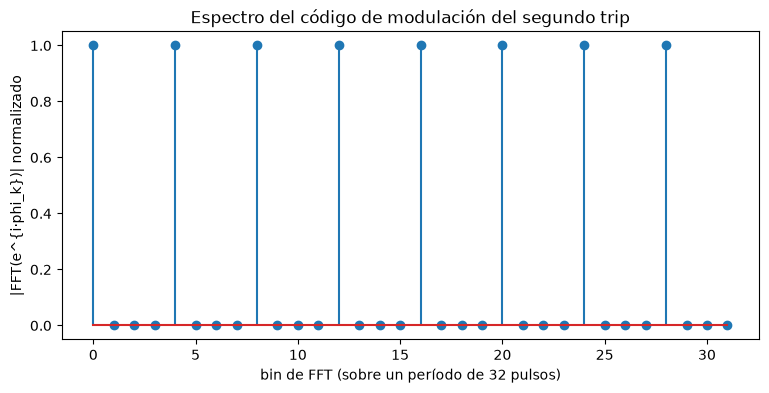

bins significativos: [ 0  4  8 12 16 20 24 28]
espaciado entre bins: [4 4 4 4 4 4 4]


In [4]:
code_seq = np.exp(1j * phi[:CODE_PERIOD])
code_spectrum = np.abs(np.fft.fft(code_seq))
code_spectrum_norm = code_spectrum / code_spectrum.max()

significant_bins = np.where(code_spectrum_norm > 0.3)[0]
spacing = np.diff(significant_bins)

fig, ax = plt.subplots()
ax.stem(np.arange(CODE_PERIOD), code_spectrum_norm)
ax.set_xlabel("bin de FFT (sobre un período de 32 pulsos)")
ax.set_ylabel("|FFT(e^{i·phi_k})| normalizado")
ax.set_title("Espectro del código de modulación del segundo trip")
plt.show()

print(f"bins significativos: {significant_bins}")
print(f"espaciado entre bins: {spacing}")
checks.append(("el código dispersa la energía en exactamente 8 réplicas (no un pedestal continuo)",
               len(significant_bins) == 8))
checks.append(("las 8 réplicas están equiespaciadas (32/8 = 4 bins) y son de igual magnitud",
               bool(np.all(spacing == CODE_PERIOD // 8)) and np.ptp(code_spectrum_norm[significant_bins]) < 1e-9))

## Prueba 2 — sesgo de velocidad del primer trip, con código vs sin código

Consecuencia directa de la Prueba 1, la que Meymaris et al. citan como la
ventaja "gratis" de SZ(8/64) sobre no codificar: al decodificar para el trip1,
el segundo trip queda esparcido en 8 réplicas — su contribución a la
autocovarianza de retardo 1 (pulse-pair) tiende a cancelarse porque
$\phi_k - \phi_{k+1}$ varía con $k$, en vez de ser una fase constante que se
sumaría coherentemente al primer trip. Sin código (ambos trips se suman "tal
cual", caso ilustrado con $\psi_k \equiv 0$) esa cancelación no existe y dominan
las réplicas más fuertes.

P2/P1=-10.0 dB  V1_sz= 5.049  V1_sin_codigo= 4.046  (verdad 5.0)


P2/P1= -5.0 dB  V1_sz= 5.032  V1_sin_codigo= 2.024  (verdad 5.0)
P2/P1=  0.0 dB  V1_sz= 5.143  V1_sin_codigo=-2.272  (verdad 5.0)


P2/P1=  5.0 dB  V1_sz= 5.535  V1_sin_codigo=-7.130  (verdad 5.0)
P2/P1= 10.0 dB  V1_sz= 5.365  V1_sin_codigo=-9.065  (verdad 5.0)


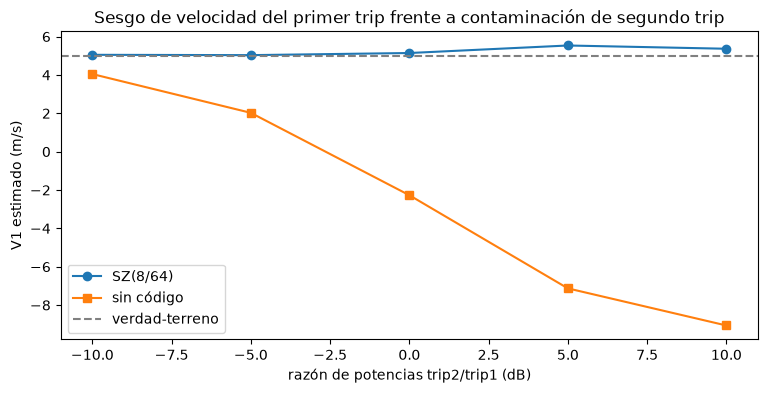

In [5]:
WAVELENGTH_M, PRT_S = 0.10, 1.0e-3
NOISE_FLOOR = 0.05
POWER1, MEAN_V1, SIGMA_V1 = 1.0, 5.0, 1.5
MEAN_V2, SIGMA_V2 = -10.0, 1.5  # segundo trip: eco distinto, velocidad distinta
ZERO_CODE = np.zeros(M)


def recover_trip1_velocity(power2_ratio_db, rng, psi_code):
    power2 = POWER1 * 10.0 ** (power2_ratio_db / 10.0)
    x1 = generate_signal_only(POWER1, MEAN_V1, SIGMA_V1, WAVELENGTH_M, PRT_S, M, rng)
    x2 = generate_signal_only(power2, MEAN_V2, SIGMA_V2, WAVELENGTH_M, PRT_S, M, rng)
    psi_prev = np.roll(psi_code, 1)  # psi_{k-1}; circular es válido porque M es múltiplo del período
    y = x1 * np.exp(1j * psi_code) + x2 * np.exp(1j * psi_prev) + complex_gaussian(rng, NOISE_FLOOR, size=M)
    y1 = y * np.exp(-1j * psi_code)  # decodificado asumiendo trip1
    return pulse_pair_velocity(y1, WAVELENGTH_M, PRT_S)


RATIO_DB_GRID = [-10.0, -5.0, 0.0, 5.0, 10.0]
N_TRIALS = 600

v1_sz, v1_nocode = [], []
for ratio_db in RATIO_DB_GRID:
    v1_sz.append(np.mean([recover_trip1_velocity(ratio_db, rng, psi) for _ in range(N_TRIALS)]))
    v1_nocode.append(np.mean([recover_trip1_velocity(ratio_db, rng, ZERO_CODE) for _ in range(N_TRIALS)]))
    print(f"P2/P1={ratio_db:5.1f} dB  V1_sz={v1_sz[-1]:6.3f}  V1_sin_codigo={v1_nocode[-1]:6.3f}  (verdad {MEAN_V1})")

fig, ax = plt.subplots()
ax.plot(RATIO_DB_GRID, v1_sz, marker="o", label="SZ(8/64)")
ax.plot(RATIO_DB_GRID, v1_nocode, marker="s", label="sin código")
ax.axhline(MEAN_V1, color="gray", linestyle="--", label="verdad-terreno")
ax.set_xlabel("razón de potencias trip2/trip1 (dB)")
ax.set_ylabel("V1 estimado (m/s)")
ax.legend()
ax.set_title("Sesgo de velocidad del primer trip frente a contaminación de segundo trip")
plt.show()

checks.append(("con código, V1 se mantiene dentro de 1 m/s de la verdad en todo el barrido -10..10 dB",
               all(abs(v - MEAN_V1) < 1.0 for v in v1_sz)))
checks.append(("sin código, el error supera 2 m/s tan pronto el segundo trip iguala o supera al primero (>= 0 dB)",
               all(abs(v1_nocode[i] - MEAN_V1) > 2.0 for i, r in enumerate(RATIO_DB_GRID) if r >= 0.0)))

## Prueba 3 — separación real: recuperar la velocidad del trip débil

Algoritmo de Meymaris et al. §2.2 (variante de Sachidananda & Zrnić 1999),
simplificado (sin ventana ni corrección de sidelobes, ver "Fuera de alcance"):
decodificar para el trip fuerte, hacer un notch en frecuencia centrado en su
velocidad media ya estimada (ancho = 1/8 del intervalo de Nyquist, uno de los
anchos que cita la fuente), invertir la FFT y recoherenciar el residuo al trip
débil multiplicando por $e^{-i\phi_k}$ — la relación $\phi_k = \psi_{k-1} -
\psi_k$ es exactamente la fase que separa a los dos trips, así que
recoherenciar al segundo es deshacer esa misma modulación.

P2/P1= -5.0 dB  V2_hat media=-10.047  desv=0.644  (verdad -10.0)
P2/P1=-10.0 dB  V2_hat media=-10.053  desv=1.190  (verdad -10.0)


P2/P1=-15.0 dB  V2_hat media=-10.241  desv=3.397  (verdad -10.0)
P2/P1=-20.0 dB  V2_hat media=-6.544  desv=10.489  (verdad -10.0)


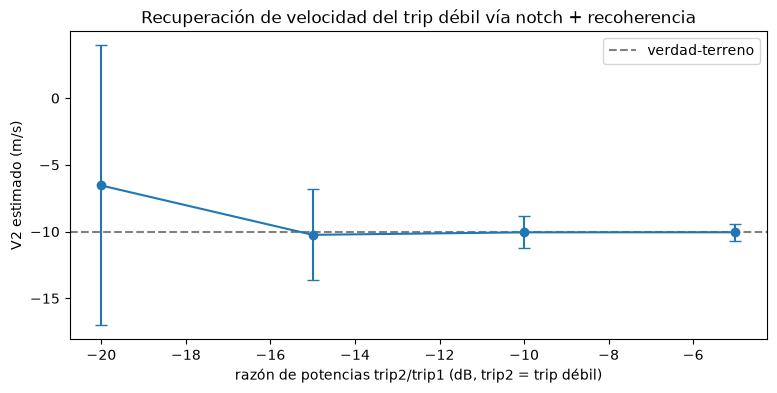

In [6]:
V_NYQUIST = WAVELENGTH_M / (4.0 * PRT_S)
NOTCH_WIDTH_MPS = 2.0 * V_NYQUIST / 8.0  # 1/8 del intervalo de Nyquist, Meymaris et al. Sec 2.1
F_K = np.fft.fftfreq(M, d=PRT_S)
V_K = F_K * WAVELENGTH_M / 2.0


def separate_weak_trip_velocity(power2_ratio_db, rng, psi_code, phi_code):
    power2 = POWER1 * 10.0 ** (power2_ratio_db / 10.0)
    x1 = generate_signal_only(POWER1, MEAN_V1, SIGMA_V1, WAVELENGTH_M, PRT_S, M, rng)
    x2 = generate_signal_only(power2, MEAN_V2, SIGMA_V2, WAVELENGTH_M, PRT_S, M, rng)
    psi_prev = np.roll(psi_code, 1)
    y = x1 * np.exp(1j * psi_code) + x2 * np.exp(1j * psi_prev) + complex_gaussian(rng, NOISE_FLOOR, size=M)
    y1 = y * np.exp(-1j * psi_code)
    v1_hat = pulse_pair_velocity(y1, WAVELENGTH_M, PRT_S)

    spectrum1 = np.fft.fft(y1)
    dv = wrap_phase((V_K - v1_hat) / V_NYQUIST * np.pi) * V_NYQUIST / np.pi  # distancia circular en velocidad
    notch = np.abs(dv) < (NOTCH_WIDTH_MPS / 2.0)
    spectrum1[notch] = 0.0
    residual = np.fft.ifft(spectrum1)
    y2 = residual * np.exp(-1j * phi_code)  # recoherenciado al trip débil
    return pulse_pair_velocity(y2, WAVELENGTH_M, PRT_S)


RATIO_DB_GRID_WEAK = [-5.0, -10.0, -15.0, -20.0]
N_TRIALS_SEP = 500

v2_mean, v2_std = [], []
for ratio_db in RATIO_DB_GRID_WEAK:
    vs = [separate_weak_trip_velocity(ratio_db, rng, psi, phi) for _ in range(N_TRIALS_SEP)]
    v2_mean.append(np.mean(vs))
    v2_std.append(np.std(vs))
    print(f"P2/P1={ratio_db:5.1f} dB  V2_hat media={v2_mean[-1]:6.3f}  desv={v2_std[-1]:5.3f}  (verdad {MEAN_V2})")

fig, ax = plt.subplots()
ax.errorbar(RATIO_DB_GRID_WEAK, v2_mean, yerr=v2_std, marker="o", capsize=4)
ax.axhline(MEAN_V2, color="gray", linestyle="--", label="verdad-terreno")
ax.set_xlabel("razón de potencias trip2/trip1 (dB, trip2 = trip débil)")
ax.set_ylabel("V2 estimado (m/s)")
ax.legend()
ax.set_title("Recuperación de velocidad del trip débil vía notch + recoherencia")
plt.show()

checks.append(("a razón moderada (-5 y -10 dB) el trip débil se recupera con sesgo < 1 m/s y desviación < 2 m/s",
               all(abs(v2_mean[i] - MEAN_V2) < 1.0 and v2_std[i] < 2.0 for i in range(2))))
checks.append(("a razón extrema (-20 dB) la degradación es clara y medible: desviación > 5 m/s",
               v2_std[-1] > 5.0))

## Fuera de alcance, declarado

- **Ancho espectral de ninguno de los dos trips.** El propio Meymaris et al.
  señalan que el ancho recuperado tras el notch queda sesgado alto por los
  lóbulos laterales que introduce el propio notch, y que corregirlo exige
  "magnitude deconvolution" (Sachidananda & Zrnić 1999; Frush & Doviak 2002) —
  no implementado aquí. Sólo se ejercita velocidad.
- **Potencia (Z) del trip fuerte vía notch + factor de corrección.** La fuente
  describe un factor de corrección (8/7, 4/3, 2 o 4 según ancho de notch) para
  recomponer la potencia total tras remover el notch — no reproducido; la
  Prueba 2 sólo mide velocidad, que no necesita ese factor.
- **Más de dos trips solapados.** La literatura extiende la propiedad de
  réplicas hasta el 8vo trip; este oráculo sólo ejercita dos.
- **Ventaneo y corrección de sidelobes** antes de la FFT del notch — se usó FFT
  rectangular sin ventana para que el notch sea un filtro exacto e invertible;
  la fuente sí ventanea, a costa de necesitar la corrección de deconvolución
  del punto anterior.
- **Clutter/RFI superpuesto a los trips** — el propio análisis cuantitativo de
  Meymaris et al. excluye clutter de sus datos de prueba; este oráculo hace lo
  mismo.
- **Interacción con polarimetría alternante** (mitad de muestras por canal,
  peor separación estadística) — nota de diseño de la propia página del
  algoritmo, no una cantidad que generadores de canal único puedan ejercitar.
- **Confirmación de que el excitador soporta fase programable pulso a pulso.**
  Este notebook no lo verifica ni lo asume resuelto — es la condición de
  hardware que la página marca como no confirmada, y que motivó preguntar
  primero antes de escribir este notebook.

In [7]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de SZ(8/64) no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] el código psi_k repite cada 32 pulsos, tal como describe la fuente (error < 1e-9 rad)
[OK] el código dispersa la energía en exactamente 8 réplicas (no un pedestal continuo)
[OK] las 8 réplicas están equiespaciadas (32/8 = 4 bins) y son de igual magnitud
[OK] con código, V1 se mantiene dentro de 1 m/s de la verdad en todo el barrido -10..10 dB
[OK] sin código, el error supera 2 m/s tan pronto el segundo trip iguala o supera al primero (>= 0 dB)
[OK] a razón moderada (-5 y -10 dB) el trip débil se recupera con sesgo < 1 m/s y desviación < 2 m/s
[OK] a razón extrema (-20 dB) la degradación es clara y medible: desviación > 5 m/s

Todas las comprobaciones dentro de tolerancia.
